## Hands On Lab Learning: 

*Simulate a skewed dataset (90% key concentration), capture its query plan, apply key salting + broadcast joins, and measure the execution-time improvement.*

## Utility Functions

In [34]:
def measure_time(df , runs = 3):

    times = []

    for i in range(runs):
        start = time.perf_counter()

        df.count()

        elapsed = time.perf_counter() - start
        times.append(elapsed)

        print(f"Run {i+1}: {elapsed:.2f} seconds")

    return times

## Step 1 — Create SparkSession

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .appName("Day5_Skew_Join_Optimization")\
        .master("local[*]")\
        .config("spark.sql.shuffle.partitions", "16")\
        .getOrCreate()

In [27]:
spark

## Create the skewed dataset

- creating orders table with 10 million data that is skewed
- creating customers table is small

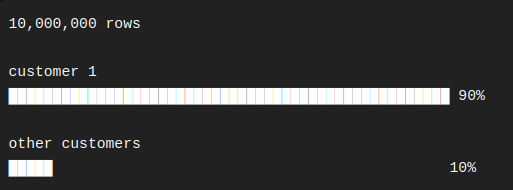

In [4]:
from pyspark.sql import functions as F

NUM_OF_ORDERS = 10_000_000

order_df = (
    spark.range(NUM_OF_ORDERS)
    .withColumn(
        "customer_id",
        F.when(
            F.col("id") < NUM_OF_ORDERS * 0.90,
            F.lit(1)
        ).otherwise(
            (F.col("id") % 99) + 2
        )
    )
    .withColumn(
        "amount",
        (F.rand(seed=42) * 1000).cast("double")
    )
    .drop("id")
)

## Step 3 — Check the dataset

In [5]:
order_df.printSchema()

root
 |-- customer_id: long (nullable = true)
 |-- amount: double (nullable = false)



In [11]:
order_df.show(10)
order_df.tail(10)

+-----------+------------------+
|customer_id|            amount|
+-----------+------------------+
|          1|  619.189370225301|
|          1|509.60188424464815|
|          1| 832.5259388871524|
|          1|263.22809041172354|
|          1| 670.2867696264135|
|          1| 517.3283545794627|
|          1| 999.1441647585968|
|          1| 69.93233728279169|
|          1| 969.6695610826326|
|          1| 795.9575617927873|
+-----------+------------------+
only showing top 10 rows


[Row(customer_id=2, amount=558.3158684358568),
 Row(customer_id=3, amount=834.3337016205473),
 Row(customer_id=4, amount=583.6462591884805),
 Row(customer_id=5, amount=385.6590688661626),
 Row(customer_id=6, amount=365.2243973762902),
 Row(customer_id=7, amount=660.1617442365844),
 Row(customer_id=8, amount=916.9147147713595),
 Row(customer_id=9, amount=578.5446554426247),
 Row(customer_id=10, amount=139.4503206216413),
 Row(customer_id=11, amount=356.3107539306688)]

## Step 4 — Verify the 90% skew

In [17]:
order_df\
.groupBy("customer_id")\
.count()\
.orderBy(F.desc('count'))\
.show(10)

+-----------+-------+
|customer_id|  count|
+-----------+-------+
|          1|9000000|
|         11|  10102|
|         28|  10101|
|         29|  10101|
|         30|  10101|
|         33|  10101|
|         93|  10101|
|         32|  10101|
|         49|  10101|
|         59|  10101|
+-----------+-------+
only showing top 10 rows


## Step 5 — Partition based on customer Id

In [18]:
order_df.rdd.getNumPartitions()

16

In [21]:
order_partitioned = order_df.repartition(16,"customer_id")

In [28]:
order_partitioned.show()

+-----------+------------------+
|customer_id|            amount|
+-----------+------------------+
|         28| 742.9788315851298|
|         29| 290.3431580128979|
|         30| 403.4827904053455|
|         33| 541.4760534038306|
|         93|   683.47279193245|
|         28|394.97444442400223|
|         29|131.95417963312818|
|         30|209.54234296100194|
|         33| 622.5449004476095|
|         93|1.3736878836451138|
|         28| 782.5608733051188|
|         29| 705.5573395451196|
|         30| 158.3465598497915|
|         33| 718.8321436065688|
|         93| 552.8286961928187|
|         28| 580.4644595663062|
|         29| 961.1760485249961|
|         30| 856.1469968581789|
|         33| 778.0048301381128|
|         93| 424.2880722344512|
+-----------+------------------+
only showing top 20 rows


In [22]:
order_partitioned.rdd.getNumPartitions()

16

## Step 6 — Measuring the Skewness

In [24]:
partition_sizes = (
    order_partitioned
    .rdd
    .mapPartitions(lambda iterator: [sum(1 for _ in iterator)])
    .collect()
)

for i, size in enumerate(partition_sizes):
    print(f"Partition {i}: {size} rows")

Partition 0: 50505 rows
Partition 1: 90910 rows
Partition 2: 50505 rows
Partition 3: 30303 rows
Partition 4: 50505 rows
Partition 5: 20202 rows
Partition 6: 50505 rows
Partition 7: 60606 rows
Partition 8: 90909 rows
Partition 9: 80808 rows
Partition 10: 60606 rows
Partition 11: 101010 rows
Partition 12: 90909 rows
Partition 13: 9030303 rows
Partition 14: 90909 rows
Partition 15: 50505 rows


## Step 7 — Create the dimension table

In [25]:
customer_df = (
    spark.range(1, 101)
    .withColumnRenamed("id", "customer_id")
    .withColumn(
        "country",
        F.when(F.col("customer_id") % 3 == 0, "Nepal")
         .when(F.col("customer_id") % 3 == 1, "India")
         .otherwise("USA")
    )
)

In [26]:
customer_df.printSchema()

root
 |-- customer_id: long (nullable = false)
 |-- country: string (nullable = false)



## Step 8 — Comparing three different scenarios

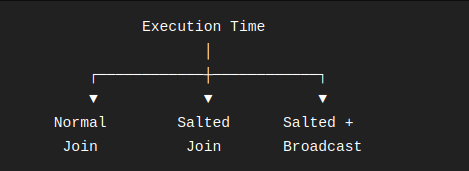

### Baseline experiment: normal join

In [30]:
normal_join = (
    order_partitioned
    .join(
        customer_df,
        "customer_id",
        "inner"
    )
)

In [ ]:
# Generating Query Plan

normal_join.explain(True)

== Parsed Logical Plan ==
'Join UsingJoin(Inner, [customer_id])
:- RepartitionByExpression [customer_id#1L], 16
:  +- Project [customer_id#1L, amount#2]
:     +- Project [id#0L, customer_id#1L, cast((rand(42) * cast(1000 as double)) as double) AS amount#2]
:        +- Project [id#0L, CASE WHEN (cast(id#0L as double) < 9000000.0) THEN cast(1 as bigint) ELSE ((id#0L % cast(99 as bigint)) + cast(2 as bigint)) END AS customer_id#1L]
:           +- Range (0, 10000000, step=1, splits=Some(16))
+- Project [customer_id#122L, CASE WHEN ((customer_id#122L % cast(3 as bigint)) = cast(0 as bigint)) THEN Nepal WHEN ((customer_id#122L % cast(3 as bigint)) = cast(1 as bigint)) THEN India ELSE USA END AS country#123]
   +- Project [id#121L AS customer_id#122L]
      +- Range (1, 101, step=1, splits=Some(16))

== Analyzed Logical Plan ==
customer_id: bigint, amount: double, country: string
Project [customer_id#1L, amount#2, country#123]
+- Join Inner, (customer_id#1L = customer_id#122L)
   :- Repartiti

In [33]:
# Measuring the time for execution 

import time 

start = time.perf_counter()

normal_join_count = normal_join.count()

normal_join_time = time.perf_counter() - start


print(f"Rows: {normal_join_count:,}")
print(f"Baseline execution time: {normal_join_time:.2f} seconds")


Rows: 10,000,000
Baseline execution time: 2.25 seconds


In [35]:
normal_join_times = measure_time(normal_join, 3)

Run 1: 2.02 seconds


Run 2: 1.64 seconds


Run 3: 1.65 seconds


In [36]:
normal_join_times

[2.017609947000892, 1.6350358720010263, 1.653720318001433]

### Salting experiment: salt join

- Dividing the large paritition into smaller ones so that we can make sure the executor 

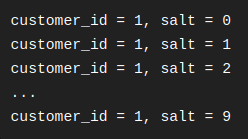
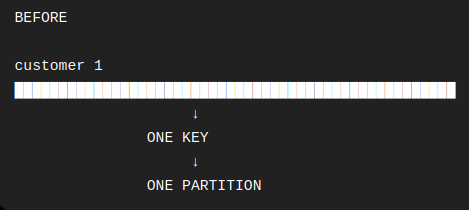

In [37]:
SALT_BUCKETS = 10

In [39]:
# Adding a Salt Column

salted_orders = (
    order_df
    .withColumn(
        "salt",
        F.when(
            F.col("customer_id") == 1,
            F.pmod(F.monotonically_increasing_id() , SALT_BUCKETS)
        ).otherwise(
            F.lit(0)
        )
    )
)

In [42]:
salted_orders.show(50)
salted_orders.tail(10)

+-----------+------------------+----+
|customer_id|            amount|salt|
+-----------+------------------+----+
|          1|  619.189370225301|   0|
|          1|509.60188424464815|   1|
|          1| 832.5259388871524|   2|
|          1|263.22809041172354|   3|
|          1| 670.2867696264135|   4|
|          1| 517.3283545794627|   5|
|          1| 999.1441647585968|   6|
|          1| 69.93233728279169|   7|
|          1| 969.6695610826326|   8|
|          1| 795.9575617927873|   9|
|          1| 448.4250584033179|   0|
|          1| 679.3959570375869|   1|
|          1| 372.4113862805264|   2|
|          1| 832.6094725399211|   3|
|          1| 747.9557402720449|   4|
|          1| 721.6183163402287|   5|
|          1|16.051221049720343|   6|
|          1| 630.7120027798567|   7|
|          1|    75.37082371587|   8|
|          1|  838.930558220017|   9|
|          1|481.33361111885284|   0|
|          1| 731.0762213878836|   1|
|          1| 541.3617395842157|   2|
|          1

[Row(customer_id=2, amount=558.3158684358568, salt=0),
 Row(customer_id=3, amount=834.3337016205473, salt=0),
 Row(customer_id=4, amount=583.6462591884805, salt=0),
 Row(customer_id=5, amount=385.6590688661626, salt=0),
 Row(customer_id=6, amount=365.2243973762902, salt=0),
 Row(customer_id=7, amount=660.1617442365844, salt=0),
 Row(customer_id=8, amount=916.9147147713595, salt=0),
 Row(customer_id=9, amount=578.5446554426247, salt=0),
 Row(customer_id=10, amount=139.4503206216413, salt=0),
 Row(customer_id=11, amount=356.3107539306688, salt=0)]

#### Verifying Salted distribution

In [43]:
salted_orders.filter(
    F.col("customer_id") == 1
).groupby("salt").count().orderBy('salt').show()

+----+------+
|salt| count|
+----+------+
|   0|900000|
|   1|900000|
|   2|900000|
|   3|900000|
|   4|900000|
|   5|900000|
|   6|900000|
|   7|900000|
|   8|900000|
|   9|900000|
+----+------+



#### Salting the dimension table to perform join 

In [46]:
salt_df = spark.range(SALT_BUCKETS).withColumnRenamed("id" , "salt")

In [47]:
salt_df.show()

+----+
|salt|
+----+
|   0|
|   1|
|   2|
|   3|
|   4|
|   5|
|   6|
|   7|
|   8|
|   9|
+----+



In [48]:
salted_customer_df = (
    customer_df.crossJoin(salt_df)
)

In [50]:
salted_customer_df.show()
salted_customer_df.count()

+-----------+-------+----+
|customer_id|country|salt|
+-----------+-------+----+
|          1|  India|   0|
|          1|  India|   1|
|          1|  India|   2|
|          1|  India|   3|
|          1|  India|   4|
|          1|  India|   5|
|          1|  India|   6|
|          1|  India|   7|
|          1|  India|   8|
|          1|  India|   9|
|          2|    USA|   0|
|          2|    USA|   1|
|          2|    USA|   2|
|          2|    USA|   3|
|          2|    USA|   4|
|          2|    USA|   5|
|          2|    USA|   6|
|          2|    USA|   7|
|          2|    USA|   8|
|          2|    USA|   9|
+-----------+-------+----+
only showing top 20 rows


1000

#### Perform Salted Join

In [51]:
salted_join = (
    salted_orders
    .join(
        salted_customer_df,
        ['customer_id' , 'salt'],
        "inner"
    )
)

In [52]:
salted_join.explain(True)

== Parsed Logical Plan ==
'Join UsingJoin(Inner, [customer_id, salt])
:- Project [customer_id#1L, amount#2, CASE WHEN (customer_id#1L = cast(1 as bigint)) THEN pmod(monotonically_increasing_id(), cast(10 as bigint)) ELSE cast(0 as bigint) END AS salt#160L]
:  +- Project [customer_id#1L, amount#2]
:     +- Project [id#0L, customer_id#1L, cast((rand(42) * cast(1000 as double)) as double) AS amount#2]
:        +- Project [id#0L, CASE WHEN (cast(id#0L as double) < 9000000.0) THEN cast(1 as bigint) ELSE ((id#0L % cast(99 as bigint)) + cast(2 as bigint)) END AS customer_id#1L]
:           +- Range (0, 10000000, step=1, splits=Some(16))
+- Join Cross
   :- Project [customer_id#122L, CASE WHEN ((customer_id#122L % cast(3 as bigint)) = cast(0 as bigint)) THEN Nepal WHEN ((customer_id#122L % cast(3 as bigint)) = cast(1 as bigint)) THEN India ELSE USA END AS country#123]
   :  +- Project [id#121L AS customer_id#122L]
   :     +- Range (1, 101, step=1, splits=Some(16))
   +- Project [id#210L AS sa

In [61]:
salted_join.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [customer_id#1L, salt#160L, amount#2, country#123]
   +- BroadcastHashJoin [customer_id#1L, salt#160L], [customer_id#122L, salt#211L], Inner, BuildRight, false, false
      :- Filter (isnotnull(customer_id#1L) AND isnotnull(salt#160L))
      :  +- Project [customer_id#1L, amount#2, CASE WHEN (customer_id#1L = 1) THEN pmod(monotonically_increasing_id(), 10) ELSE 0 END AS salt#160L]
      :     +- Project [CASE WHEN (cast(id#0L as double) < 9000000.0) THEN 1 ELSE ((id#0L % 99) + 2) END AS customer_id#1L, (rand(42) * 1000.0) AS amount#2]
      :        +- Range (0, 10000000, step=1, splits=16)
      +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, false], input[2, bigint, false]),false), [plan_id=1464]
         +- BroadcastNestedLoopJoin BuildRight, Cross
            :- Project [id#121L AS customer_id#122L, CASE WHEN ((id#121L % 3) = 0) THEN Nepal WHEN ((id#121L % 3) = 1) THEN India ELSE USA END AS co

#### Measure Salted Join


In [53]:
salted_join_times = measure_time(salted_join , 3)

Run 1: 1.39 seconds
Run 2: 0.93 seconds


Run 3: 1.08 seconds


In [54]:
salted_join_times

[1.3851911739984644, 0.9252456920003169, 1.0768952859980345]

### Salting + Explicit Broadcast


In [56]:
from pyspark.sql.functions import broadcast

salted_broadcast_join = (
    salted_orders
    .join(
        broadcast(salted_customer_df),
        ["customer_id", 'salt'],
        "inner"
    )
)

In [59]:
salted_broadcast_join.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [customer_id#1L, salt#160L, amount#2, country#123]
   +- BroadcastHashJoin [customer_id#1L, salt#160L], [customer_id#122L, salt#211L], Inner, BuildRight, false, false
      :- Filter (isnotnull(customer_id#1L) AND isnotnull(salt#160L))
      :  +- Project [customer_id#1L, amount#2, CASE WHEN (customer_id#1L = 1) THEN pmod(monotonically_increasing_id(), 10) ELSE 0 END AS salt#160L]
      :     +- Project [CASE WHEN (cast(id#0L as double) < 9000000.0) THEN 1 ELSE ((id#0L % 99) + 2) END AS customer_id#1L, (rand(42) * 1000.0) AS amount#2]
      :        +- Range (0, 10000000, step=1, splits=16)
      +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, false], input[2, bigint, false]),false), [plan_id=2774]
         +- BroadcastNestedLoopJoin BuildRight, Cross
            :- Project [id#121L AS customer_id#122L, CASE WHEN ((id#121L % 3) = 0) THEN Nepal WHEN ((id#121L % 3) = 1) THEN India ELSE USA END AS co

In [60]:
salted_broadcast_join.explain(True)

== Parsed Logical Plan ==
'Join UsingJoin(Inner, [customer_id, salt])
:- Project [customer_id#1L, amount#2, CASE WHEN (customer_id#1L = cast(1 as bigint)) THEN pmod(monotonically_increasing_id(), cast(10 as bigint)) ELSE cast(0 as bigint) END AS salt#160L]
:  +- Project [customer_id#1L, amount#2]
:     +- Project [id#0L, customer_id#1L, cast((rand(42) * cast(1000 as double)) as double) AS amount#2]
:        +- Project [id#0L, CASE WHEN (cast(id#0L as double) < 9000000.0) THEN cast(1 as bigint) ELSE ((id#0L % cast(99 as bigint)) + cast(2 as bigint)) END AS customer_id#1L]
:           +- Range (0, 10000000, step=1, splits=Some(16))
+- ResolvedHint (strategy=broadcast)
   +- Join Cross
      :- Project [customer_id#122L, CASE WHEN ((customer_id#122L % cast(3 as bigint)) = cast(0 as bigint)) THEN Nepal WHEN ((customer_id#122L % cast(3 as bigint)) = cast(1 as bigint)) THEN India ELSE USA END AS country#123]
      :  +- Project [id#121L AS customer_id#122L]
      :     +- Range (1, 101, step

In [57]:
salted_broadcast_times = measure_time(salted_broadcast_join , 3)

Run 1: 0.78 seconds


Run 2: 0.96 seconds
Run 3: 0.75 seconds


In [62]:
print(f"Normal Join" , normal_join_times)
print(f"Salt Join" , salted_join_times)
print(f"Salt + Broadcast Join" , salted_broadcast_times)

Normal Join [2.017609947000892, 1.6350358720010263, 1.653720318001433]
Salt Join [1.3851911739984644, 0.9252456920003169, 1.0768952859980345]
Salt + Broadcast Join [0.7837485649979499, 0.9562029660010012, 0.7504848150019825]
